### **Objective**

Apply your knowledge of `NumPy`, `Pandas`, and `Matplotlib` to analyze a real-world dataset. Utilize advanced statistical functions and array operations in `NumPy`, and integrate these with `Pandas` for data manipulation and `Matplotlib` for visualization.

---

### **Dataset**

You will work with the "Global Power Plant Database" provided by the World Resources Institute, which contains detailed information about power plants worldwide. This dataset is ideal for practicing array manipulations, statistical analysis, and time series data handling.
[Download the dataset here](https://datasets.wri.org/dataset/globalpowerplantdatabase).
or you can download it directly
[Here](https://github.com/devtlv/Datasets-DA-Bootcamp-2-/raw/refs/heads/main/Week%206%20-%20Applications%20for%20Data%20Analysis/W6D2%20-%20Advanced%20Numpy/globalpowerplantdatabasev130.zip).

---

### **Tasks**

1. Data Import and Cleaning:
    - Import the dataset using `Pandas`.
    - Identify missing values and handle them appropriately.
    - Use `NumPy` to convert relevant columns to numerical types if necessary.
2. Exploratory Data Analysis:
    - Utilize `Pandas` to summarize key statistics (mean, median, standard deviation) for numerical columns.
    - Explore the distribution of power plants by country and fuel type.
3. Statistical Analysis:
    - Perform a statistical analysis of power output by fuel type using `NumPy`'s statistical functions.
    - Use hypothesis testing to determine if the mean power output differs significantly between different fuel types.
4. Time Series Analysis:
    - If the dataset includes time-related data (like year of establishment), use `NumPy` to analyze trends over time.
    - Explore how the mix of fuel types for power generation has evolved over the years.
5. Advanced Visualization:
    - Create visualizations using `Matplotlib` and `Seaborn` to illustrate your findings.
    - Consider plotting the geographical distribution of power plants using latitude and longitude data, if available.
6. Matrix Operations in Real-World Context:
    - Demonstrate matrix operations by analyzing relationships between different attributes (e.g., fuel type, capacity, and geographic location).
    - Discuss the relevance of eigenvectors and eigenvalues in this context.
7. Integrating NumPy with Pandas and Matplotlib:
    - Show how `NumPy` can be used to enhance data manipulation in `Pandas` and data visualization in `Matplotlib`.
    - Provide examples, such as using `NumPy` arrays for complex filtering in `Pandas` or for creating sophisticated plots in `Matplotlib`.

### **Submit your Daily Challenge**

Prepare a report including your code, findings, and visualizations. Discuss how `NumPy`, `Pandas`, and `Matplotlib` were used in your analysis, and present any interesting insights you discovered about the global power plant landscape.


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

### 1. Data Import and Cleaning:

Before deciding how to handle missing values, we need to see _how much_ is missing and _where_, because the right strategy depends on the pattern:

- A column missing for a structural reason (e.g `other_fuel2` is NaN whenever a plant only reports one fuel type) shouldn't be imputed. It's 'not applicable', not 'broken'.
- A column that's mostly empty everywhere (> 80% missing) usually isn't worth imputing. Filling 80% of a column would mean inventing data, not filling gaps.


In [ ]:
df = pd.read_csv("global_power_plant_database.csv", low_memory=False)

print(df.shape)
df.info()
df

(34936, 36)
<class 'pandas.DataFrame'>
RangeIndex: 34936 entries, 0 to 34935
Data columns (total 36 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   country                         34936 non-null  str    
 1   country_long                    34936 non-null  str    
 2   name                            34936 non-null  str    
 3   gppd_idnr                       34936 non-null  str    
 4   capacity_mw                     34936 non-null  float64
 5   latitude                        34936 non-null  float64
 6   longitude                       34936 non-null  float64
 7   primary_fuel                    34936 non-null  str    
 8   other_fuel1                     1944 non-null   str    
 9   other_fuel2                     276 non-null    str    
 10  other_fuel3                     92 non-null     str    
 11  commissioning_year              17447 non-null  float64
 12  owner                          

,country,country_long,name,gppd_idnr,capacity_mw,latitude,longitude,primary_fuel,other_fuel1,other_fuel2,...,estimated_generation_gwh_2013,estimated_generation_gwh_2014,estimated_generation_gwh_2015,estimated_generation_gwh_2016,estimated_generation_gwh_2017,estimated_generation_note_2013,estimated_generation_note_2014,estimated_generation_note_2015,estimated_generation_note_2016,estimated_generation_note_2017
0,AFG,Afghanistan,Kajaki Hydroelectric Power Plant Afghanistan,GEODB0040538,33.0,32.3220,65.1190,Hydro,NaN,NaN,...,123.77,162.90,97.39,137.76,119.50,HYDRO-V1,HYDRO-V1,HYDRO-V1,HYDRO-V1,HYDRO-V1
1,AFG,Afghanistan,Kandahar DOG,WKS0070144,10.0,31.6700,65.7950,Solar,NaN,NaN,...,18.43,17.48,18.25,17.70,18.29,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE
2,AFG,Afghanistan,Kandahar JOL,WKS0071196,10.0,31.6230,65.7920,Solar,NaN,NaN,...,18.64,17.58,19.10,17.62,18.72,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE
3,AFG,Afghanistan,Mahipar Hydroelectric Power Plant Afghanistan,GEODB0040541,66.0,34.5560,69.4787,Hydro,NaN,NaN,...,225.06,203.55,146.90,230.18,174.91,HYDRO-V1,HYDRO-V1,HYDRO-V1,HYDRO-V1,HYDRO-V1
4,AFG,Afghanistan,Naghlu Dam Hydroelectric Power Plant Afghanistan,GEODB0040534,100.0,34.6410,69.7170,Hydro,NaN,NaN,...,406.16,357.22,270.99,395.38,350.80,HYDRO-V1,HYDRO-V1,HYDRO-V1,HYDRO-V1,HYDRO-V1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34931,ZMB,Zambia,Ndola,WRI1022386,50.0,-12.9667,28.6333,Oil,NaN,NaN,...,NaN,NaN,NaN,NaN,183.79,NO-ESTIMATION,NO-ESTIMATION,NO-ESTIMATION,NO-ESTIMATION,CAPACITY-FACTOR-V1
34932,ZMB,Zambia,Nkana,WRI1022384,20.0,-12.8167,28.2000,Oil,NaN,NaN,...,NaN,NaN,NaN,NaN,73.51,NO-ESTIMATION,NO-ESTIMATION,NO-ESTIMATION,NO-ESTIMATION,CAPACITY-FACTOR-V1
34933,ZMB,Zambia,Victoria Falls,WRI1022380,108.0,-17.9167,25.8500,Hydro,NaN,NaN,...,575.78,575.78,548.94,579.90,578.32,HYDRO-V1,HYDRO-V1,HYDRO-V1,HYDRO-V1,HYDRO-V1
34934,ZWE,Zimbabwe,Hwange Coal Power Plant Zimbabwe,GEODB0040404,920.0,-18.3835,26.4700,Coal,NaN,NaN,...,NaN,NaN,NaN,NaN,2785.10,NO-ESTIMATION,NO-ESTIMATION,NO-ESTIMATION,NO-ESTIMATION,CAPACITY-FACTOR-V1


In [ ]:
def completeness_rating(pct_missing):
    """
    Bucket a column's missing-percentage into a completeness rating.

    Args:
        pct_missing (float): Percentage of values missing in a column (0 - 100).

    Returns:
        str: One of 'complete', 'mostly complete', 'incomplete', or 'sparse',
        based on how much of the column is actually present.
    """
    pct_present = 100 - pct_missing
    if pct_present > 99:
        return "complete"
    elif pct_present > 95:
        return "mostly complete"
    elif pct_present > 80:
        return "incomplete"
    return "sparse"


def missingness_report(dataframe):
    """
    Build a per column summary of missing values, sorted worst first.

    Args:
        dataframe (pandas.DataFrame): The dataframe to check for missing values.

    Returns:
        pandas.DataFrame: One row per column that has at least one missing value,
        with its missing count, missing percentage, and completeness rating,
        sorted worst (most missing) first.
    """
    missing = dataframe.isnull().sum()
    missing_pct = (missing / len(dataframe) * 100).round(2)

    report = pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct})
    report = report[report["missing_count"] > 0].sort_values(
        "missing_pct", ascending=False
    )
    report["rating"] = report["missing_pct"].apply(completeness_rating)

    return report

In [ ]:
missingness_report(df)

,missing_count,missing_pct,rating
other_fuel3,34844,99.74,sparse
other_fuel2,34660,99.21,sparse
other_fuel1,32992,94.44,sparse
generation_gwh_2013,28519,81.63,sparse
generation_gwh_2014,27710,79.32,sparse
generation_gwh_2015,26733,76.52,sparse
generation_gwh_2016,25792,73.83,sparse
generation_gwh_2017,25436,72.81,sparse
generation_gwh_2018,25299,72.42,sparse
generation_gwh_2019,25277,72.35,sparse


### Cleaning strategy

Rather than dropping rows with missing values, we build a cleaned copy of the dataframe that keeps only the columns we need with correct dtypes:

- **Structural / sparse columns are dropped from the working set** (`other_fuel1/2/3`, yearly `generation_gwh_*`, `wepp_id`, `owner`, etc..). They're either not applicable to most rows or too sparse to analyze reliably. We're not 'losing' this data, just not carrying unusable columns into every task.
- **`estimated_generation_gwh_2017` is kept and renamed to `generation_gwh_est`**. At ~95% complete it's the most usable output metric so it becomes the generation figure used throughout tasks, instead of juggling 7 mostly empty yearly columns.
- **`commissioning_year` keeps its NaNs** since we don't want to invent a founding year for a plant that didn't report one, but is cast to pandas nullable `Int64` which can hold NaN values.
- **`capacity_mw`, `latitude`, `longitude`, `generation_gwh_est`** are coerced with `pd.to_numeric` and any unparseable value becomes `NaN` instead of 'breaking' the column.


In [ ]:
def clean_power_plants(dataframe):
    """
    Produce a cleaned, task ready copy of the raw power plant dataframe.

    Args:
        dataframe (pandas.DataFrame): The raw power plant dataframe, as read directly
        from the CSV.

    Returns:
        pandas.DataFrame: A cleaned copy containing only the columns needed for tasks 2-7,
        with whitespace trimmed text columns, NumPy cast numeric columns, and `commissioning_year` stored as nullable Int64.
    """
    cols_to_keep = [
        "country",
        "country_long",
        "name",
        "gppd_idnr",
        "capacity_mw",
        "latitude",
        "longitude",
        "primary_fuel",
        "commissioning_year",
        "estimated_generation_gwh_2017",
    ]
    cleaned = dataframe[cols_to_keep].copy()

    # Strip any whitespace so groupby / value_counts don't split identical categories
    for col in ["country", "country_long", "name", "primary_fuel"]:
        cleaned[col] = cleaned[col].str.strip()

    numeric_cols = [
        "capacity_mw",
        "latitude",
        "longitude",
        "estimated_generation_gwh_2017",
    ]

    for col in numeric_cols:
        coerced = pd.to_numeric(cleaned[col], errors="coerce")
        cleaned[col] = np.asarray(coerced, dtype=np.float64)

    # Int64 is the only way to keep 'year' as an integer type while allowing missing values, and a plain NumPy int array can't hold NaN.
    year_values = pd.to_numeric(cleaned["commissioning_year"], errors="coerce")
    cleaned["commissioning_year"] = pd.array(np.round(year_values), dtype="Int64")

    cleaned = cleaned.rename(
        columns={"estimated_generation_gwh_2017": "generation_gwh_est"}
    )

    return cleaned

In [ ]:
df_clean = clean_power_plants(df)
df_clean.info()
df_clean.head()

<class 'pandas.DataFrame'>
RangeIndex: 34936 entries, 0 to 34935
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   country             34936 non-null  str    
 1   country_long        34936 non-null  str    
 2   name                34936 non-null  str    
 3   gppd_idnr           34936 non-null  str    
 4   capacity_mw         34936 non-null  float64
 5   latitude            34936 non-null  float64
 6   longitude           34936 non-null  float64
 7   primary_fuel        34936 non-null  str    
 8   commissioning_year  17447 non-null  Int64  
 9   generation_gwh_est  33138 non-null  float64
dtypes: Int64(1), float64(4), str(5)
memory usage: 2.7 MB


,country,country_long,name,gppd_idnr,capacity_mw,latitude,longitude,primary_fuel,commissioning_year,generation_gwh_est
0,AFG,Afghanistan,Kajaki Hydroelectric Power Plant Afghanistan,GEODB0040538,33.0,32.322,65.1190,Hydro,<NA>,119.50
1,AFG,Afghanistan,Kandahar DOG,WKS0070144,10.0,31.670,65.7950,Solar,<NA>,18.29
2,AFG,Afghanistan,Kandahar JOL,WKS0071196,10.0,31.623,65.7920,Solar,<NA>,18.72
3,AFG,Afghanistan,Mahipar Hydroelectric Power Plant Afghanistan,GEODB0040541,66.0,34.556,69.4787,Hydro,<NA>,174.91
4,AFG,Afghanistan,Naghlu Dam Hydroelectric Power Plant Afghanistan,GEODB0040534,100.0,34.641,69.7170,Hydro,<NA>,350.80


### 2. EDA

**Key statistics:** Use Pandas' `.agg()` to summarize the numeric columns. We report mean _and_ median together deliberately for a skewed distribution (A few huge power plants, and many small ones). We also report `missing_pct` alongside the stats so the numbers are never read without their completeness context (e.g `commissioning_year` stats are only computed from the ~50% of plants that report one).

**Distribution by country / fuel type:** We use `value_counts()` plus a percentage column, wrapped in one reusable function (`distribution_by`) so the same logic served both the country breakdown and the fuel type breakdown.


In [ ]:
def summarize_numeric(dataframe, columns):
    """
    Compute mean / median / std / min / max for a set of numeric columns.

    Args:
        dataframe (pandas.DataFrame): The dataframe containing the columns to summarize.
        columns (list[str]): Names of the numeric columns to compute statistics for.

    Returns:
        pandas.DataFrame: One row per input column with its mean, median, std, min, max,
        and missing value percentage.
    """
    summary = dataframe[columns].agg(["mean", "median", "std", "min", "max"]).T

    # missing_pct goes with the stats so that they will never be read out of context.
    # commissioning_year stats only reflect the ~50% of plants that report one.
    summary["missing_pct"] = (dataframe[columns].isnull().mean() * 100).round(2)

    return summary.round(2)


def distribution_by(dataframe, column, top_n=None):
    """
    Compute value counts and percentage share for a categorical column.

    Args:
        dataframe (pandas.DataFrame): The dataframe containing the column to profile.
        column (str): Name of the categorical column to count values for.
        top_n (int, optional): If give, only the top_n most frequent values are returned. Defaults to None (return all values).

    Returns:
        pandas.DataFrame: Value counts and percentage share per category, sorted from most to least frequent.
    """
    counts = dataframe[column].value_counts(dropna=True)
    pct = (counts / counts.sum() * 100).round(2)
    result = pd.DataFrame({"count": counts, "pct": pct})

    if top_n is not None:
        result = result.head(top_n)

    return result

In [ ]:
summarize_numeric(df_clean, ["capacity_mw", "generation_gwh_est", "commissioning_year"])

,mean,median,std,min,max,missing_pct
capacity_mw,163.36,16.74,489.64,1.0,22500.00,0.00
generation_gwh_est,716.44,37.59,2484.36,0.0,82810.77,5.15
commissioning_year,1997.41,2007.00,23.40,1896.0,2020.00,50.06


In [ ]:
distribution_by(df_clean, "country_long", top_n=15)

,count,pct
country_long,,
United States of America,9833,28.15
China,4235,12.12
United Kingdom,2751,7.87
Brazil,2360,6.76
France,2155,6.17
India,1589,4.55
Germany,1309,3.75
Canada,1159,3.32
Spain,829,2.37


In [ ]:
distribution_by(df_clean, "primary_fuel")

,count,pct
primary_fuel,,
Solar,10665,30.53
Hydro,7156,20.48
Wind,5344,15.30
Gas,3998,11.44
Coal,2330,6.67
Oil,2320,6.64
Biomass,1430,4.09
Waste,1068,3.06
Nuclear,195,0.56


### 3. Statistical Analysis: Power Output by Fuel Type

**Metric used:** `generation_gwh_est` (the cleaned, 95% complete estimated 2017 generation
column) - this is genuine 'power output,' unlike `capacity_mw` which is installed capacity,
not actual energy produced.

**Descriptive stats:** computed per fuel type with NumPy's own statistical functions
(`np.mean`, `np.median`, `np.std`, `np.percentile`) - not Pandas' `.describe()` per Task 3
instruction. We require at least 30 non-null observations per fuel type to report stats for
it. Fuel types below that are excluded and named explicitly rather than silently dropped.

**Hypothesis test:** Task 2 already showed `generation_gwh_est` is heavily right skewed
(mean 716 vs. median 37.6 GWh) - a classic case where a standard ANOVA's normality
assumption is unsafe (a handful of huge plants, up to 82,810 GWh, would dominate a
raw-value F-test).


In [ ]:
def fuel_type_stats(dataframe, value_col, group_col, min_n=30):
    """
    Compute per fuel type descriptive statistics using NumPy statistical functions.

    Args:
        dataframe (pandas.DataFrame): The dataframe containing the value and group columns.
        value_col (str): Name of the numeric column to compute statistics on.
        group_col (str): Name of the categorical column to group by.
        min_n (int, optional): Minimum number of non-null observations a group must have to be included. Defaults to 30.

    Returns:
        tuple[pandas.DataFrame, list]: A table of per group mean / median / std / p25, p75 (sorted by mean, descending), and a list of group labels that were excluded for having fewer than min_n observations.
    """
    rows = []
    excluded = []
    for fuel in dataframe[group_col].dropna().unique():
        values = (
            dataframe.loc[dataframe[group_col] == fuel, value_col]
            .dropna()
            .to_numpy(dtype=np.float64)
        )
        if values.size < min_n:
            excluded.append(fuel)
            continue
        rows.append(
            {
                "primary_fuel": fuel,
                "n": values.size,
                "mean": np.mean(values),
                "median": np.median(values),
                "std": np.std(values, ddof=1),
                "p25": np.percentile(values, 25),
                "p75": np.percentile(values, 75),
            }
        )

    table = (
        pd.DataFrame(rows).sort_values("mean", ascending=False).reset_index(drop=True)
    )

    return table.round(2), excluded


def f_statistic(codes, values, k):
    """
    Compute the one way ANOVA F-statistic from group-coded values.

    Args:
        codes (numpy.ndarray): Integer group label per observation (e.g from pandas.factorize), values 0 through k-1.
        values (numpy.ndarray): The numeric values (or ranks) to compute the F-statistic on.
        k (int): Number of distinct groups.

    Returns:
        float: The one way ANOVA F-statistic. The ratio of between group variance to within group variance.
    """
    n_total = values.size
    grand_mean = np.mean(values)
    group_n = np.bincount(codes, minlength=k).astype(np.float64)
    group_sum = np.bincount(codes, weights=values, minlength=k)
    group_sumsq = np.bincount(codes, weights=values**2, minlength=k)
    group_mean = group_sum / group_n

    ss_between = np.sum(group_n * (group_mean - grand_mean) ** 2)
    ss_within = np.sum(group_sumsq - (group_sum**2) / group_n)

    df_between = k - 1
    df_within = n_total - k

    return (ss_between / df_between) / (ss_within / df_within)


def anova_permutation_test(
    dataframe, value_col, group_col, min_n=30, n_permutations=2000, seed=42
):
    """
    Test whether power output differs significantly across fuel types using a rank based, NumPy only permutation ANOVA (no distributional assumptions).

    Args:
        dataframe (pandas.DataFrame): The dataframe containing the value and group column.
        value_col (str): Name of the numeric column to test (e.g generation output).
        group_col (str): Name of the categorical column defining the groups (e.g fuel type).
        min_n (int, optional): Minimum non-null observations a group needs to be included in the test. Defaults to 30.
        n_permutations (int, optional): Number of random shuffles used to build the null distribution, Defaults to 2000.
        seed (int, optional): Seed for the random number generator, for reproducibility. Defaults to 42.

    Returns:
        dict: The tested group labels, group count (k), sample size (n), the observed rank based F-statistic, the resulting p-value, and the mean F-statistic of the permuted (null) distribution.
    """
    sub = dataframe[[value_col, group_col]].dropna()
    counts = sub[group_col].value_counts()
    sub = sub[sub[group_col].isin(counts[counts >= min_n].index)]

    # rank transform first: neutralizes the outsized influence of a handful of huge plants
    ranks = pd.Series(sub[value_col].to_numpy()).rank().to_numpy()
    codes, uniques = pd.factorize(sub[group_col])
    k = len(uniques)

    observed_f = f_statistic(codes, ranks, k)

    rng = np.random.default_rng(seed)
    permuted_f = np.empty(n_permutations)
    for i in range(n_permutations):
        permuted_f[i] = f_statistic(codes, rng.permutation(ranks), k)

    # +1/+1 correction a permutation p-value can never be reported as exactly 0
    p_value = (np.sum(permuted_f >= observed_f) + 1) / (n_permutations + 1)

    return {
        "groups_tested": list(uniques),
        "k": k,
        "n": len(sub),
        "observed_F": observed_f,
        "p_value": p_value,
        "null_F_mean": permuted_f.mean(),
    }

In [ ]:
fuel_stats_table, excluded_fuels = fuel_type_stats(
    df_clean, "generation_gwh_est", "primary_fuel", min_n=30
)
print(f"Excluded (fewer than 30 generation values): {excluded_fuels}")

fuel_stats_table

Excluded (fewer than 30 generation values): ['Biomass', 'Wave and Tidal', 'Petcoke', 'Storage', 'Cogeneration']


,primary_fuel,n,mean,median,std,p25,p75
0,Nuclear,193,15038.41,14219.26,9179.83,8188.01,19365.15
1,Coal,2306,4186.23,2923.61,4675.79,974.53,5847.22
2,Gas,3947,1525.69,560.39,2459.02,98.94,2118.28
3,Hydro,7156,494.89,69.43,2166.10,17.29,290.89
4,Other,42,393.51,246.83,556.95,89.21,410.13
5,Geothermal,158,380.35,150.82,682.55,111.38,396.64
6,Oil,2263,221.30,7.38,891.96,2.93,59.00
7,Wind,5343,128.97,67.47,250.40,21.76,113.82
8,Solar,10665,32.59,10.13,78.79,4.11,31.50
9,Waste,1065,7.67,1.93,17.24,0.86,5.61


In [ ]:
anova_result = anova_permutation_test(
    df_clean, "generation_gwh_est", "primary_fuel", min_n=30
)
anova_result

{'groups_tested': ['Hydro',
  'Solar',
  'Gas',
  'Oil',
  'Other',
  'Nuclear',
  'Coal',
  'Wind',
  'Waste',
  'Geothermal'],
 'k': 10,
 'n': 33138,
 'observed_F': np.float64(3162.733778043416),
 'p_value': np.float64(0.0004997501249375312),
 'null_F_mean': np.float64(1.0000589683038235)}

### 4. Time Series Analysis

**What 'time series' means here:** each power plant has a `commissioning_year` - the year it was built and started operating. By grouping plants by that year, we can see how much new power-generating capacity gets added each year, and which fuel types that new capacity comes from. That allows us to watch the 'energy mix' changes.

Only about half of all plants report a `commissioning_year`, and the rest is missing. So we can only check half of the plants where we know the build year.

The most recent years (2017-2019) show _less_ new capacity being added than the years before them. This could be due to the fact that newly built plants often take time to report their activity, so recent years look artificially low because the dataset doesn't have all the information yet, and not because fewer plants were actually built.

**What we compute:**

1. **Total new capacity (megawatts) added per year**, plus a straight line trend through it (building more or less each year over time on average?) and a 5-year moving average (smoothing that ignored noisy years).
2. **The share of new capacity coming from each fuel type, by decade**, instead of asking 'how many megawatts', we ask 'what percentage was `fuel_type` in previous decades out of all the new capacity?'.


In [ ]:
def capacity_added_per_year(dataframe, exclude_years=None):
    """
    Compute total new capacity (megawatts) commissioned per year, with a linear trend line and a 5-year moving average using NumPy.

    Args:
        dataframe (pandas.DataFrame): Cleaned power plant data with 'commissioning_year' and 'capacity_mw' columns.
        exclude_years (list[int], optional): Years to leave out of the trend calculation (e.g a partial / cutoff final year). Defaults to None.

    Returns:
        dict: 'years_series' (pandas.Series of total megawatts added per year), 'slope' (average megawatts change per year, from a NumPy linear fit), 'moving_avg' (5-year moving average, as a NumPy array).
    """
    have_year = dataframe.dropna(subset=["commissioning_year", "capacity_mw"]).copy()

    if exclude_years:
        have_year = have_year[~have_year["commissioning_year"].isin(exclude_years)]

    yearly_totals = have_year.groupby("commissioning_year")["capacity_mw"].sum()
    full_range = range(
        int(yearly_totals.index.min()), int(yearly_totals.index.max()) + 1
    )
    yearly_totals = yearly_totals.reindex(full_range, fill_value=0.0)

    x = yearly_totals.index.to_numpy(dtype=np.float64)
    y = yearly_totals.to_numpy(dtype=np.float64)

    # np.polyfit with degree 1 fits a straight line (y = slope*x + intercept)
    # the slope tells us the average MW change per year across the whole perios
    slope, intercept = np.polyfit(x, y, deg=1)

    # a moving average smooths out single noisy years so the overall shape is easier to read
    # np.convolve with a 'flat' kernel is a fast way to average each 5-year window without writing
    # an explicit loop
    window = 5
    kernel = np.ones(window) / window
    moving_avg = np.convolve(y, kernel, mode="valid")

    return {"years_series": yearly_totals, "slope": slope, "moving_avg": moving_avg}


def fuel_mix_share_by_decade(dataframe):
    """
    Compute each fuel type's percentage share of newly commissioned capacity, grouped by the decade plants were built in.

    Args:
        dataframe (pandas.DataFrame): Cleaned power plant data with 'commissioning_year', 'capacity_mw', and 'primary_fuel' columns.

    Returns:
        pandas.DataFrame: Rows are decades, columns are fuel types, values are the percentage of that decade's new capacity from that fuel type.
    """
    have_year = dataframe.dropna(subset=["commissioning_year", "capacity_mw"]).copy()
    have_year["decade"] = (have_year["commissioning_year"].astype(int) // 10) * 10

    pivot = pd.crosstab(
        have_year["decade"],
        have_year["primary_fuel"],
        values=have_year["capacity_mw"],
        aggfunc="sum",
    ).fillna(0)

    # NumPy division: each row (decade) divided by its own row total, turning raw megawatts into a percentage share.
    # [:, None] reshapes the row-sum array so NumPy can divide every column by it, row by row
    row_totals = pivot.to_numpy().sum(axis=1)
    pct_values = np.divide(pivot.to_numpy(), row_totals[:, None]) * 100

    return pd.DataFrame(pct_values, index=pivot.index, columns=pivot.columns).round(1)

In [ ]:
trend = capacity_added_per_year(df_clean, exclude_years=[2020])
print(f"Average MW added per year (trend slope): {trend['slope']:.1f}")
trend["years_series"].tail(15)

Average MW added per year (trend slope): 933.9


commissioning_year
2005     88018.52160
2006    134189.98620
2007    123710.63400
2008    120301.16365
2009    122458.61340
2010    145791.25100
2011    115751.14640
2012    132796.61120
2013    149774.84336
2014    129127.47138
2015    132524.48349
2016    134387.67754
2017     59962.39000
2018     39542.30000
2019     23230.40000
Name: capacity_mw, dtype: float64

In [ ]:
fuel_mix_share_by_decade(df_clean).loc[1970:]

primary_fuel,Biomass,Coal,Cogeneration,Gas,Geothermal,Hydro,Nuclear,Oil,Other,Petcoke,Solar,Storage,Waste,Wind
decade,,,,,,,,,,,,,,
1970,0.4,42.5,0.0,20.9,0.3,20.7,9.8,5.3,0.0,0.0,0.0,0.0,0.1,0.0
1980,0.5,39.3,0.1,14.7,0.4,19.6,20.4,4.2,0.0,0.1,0.0,0.0,0.7,0.1
1990,0.7,47.0,0.1,32.2,0.4,13.6,1.5,2.8,0.1,0.4,0.0,0.0,0.8,0.4
2000,0.5,48.5,0.0,34.7,0.1,9.1,1.0,1.8,0.1,0.0,0.0,0.0,0.2,3.9
2010,0.7,50.1,0.0,19.3,0.1,12.1,0.5,4.1,0.1,0.0,4.0,0.1,0.2,8.8
2020,0.0,0.0,0.0,20.5,0.0,0.0,0.0,0.0,0.0,0.0,33.2,0.2,1.9,44.2


### 5. Advanced Visualization

We picked each chart type to match the specific question it answers, rather than
defaulting to "a bar chart" or "a pie chart" for everything - pie charts especially
get avoided here since we have up to 15 fuel-type categories, and a pie with that many
slices is nearly impossible to read accurately.


In [ ]:
# One fixed color per fuel type, reused across every chart in this section so a
# reader learns the color code once instead of re-decoding it chart by chart.
FUEL_COLORS = {
    "Coal": "#000000",
    "Gas": "#D55E00",
    "Hydro": "#0072B2",
    "Nuclear": "#CC79A7",
    "Oil": "#F0E442",
    "Solar": "#E69F00",
    "Wind": "#56B4E9",
    "Other": "#999999",
}
TOP_FUELS = ["Coal", "Gas", "Hydro", "Nuclear", "Oil", "Solar", "Wind"]

### 5a. How big are power plants, really?

A regular histogram of `capacity_mw` would be almost useless here. we already know
from Task 2 that a handful of huge plants sit next to thousands of tiny ones, so a
normal chart would just show one tall bar near zero and nothing else. Putting the
x-axis on a **log scale** (each step multiplies by 10 instead of adding a fixed amount)
spreads the small plants and the huge plants out so both are visible in the same chart.


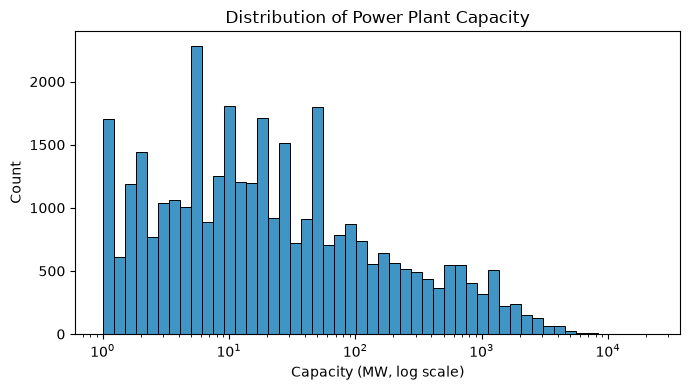

In [ ]:
fig, ax = plt.subplots(figsize=(7, 4))
sns.histplot(
    df_clean["capacity_mw"], bins=50, log_scale=True, ax=ax, color=FUEL_COLORS["Hydro"]
)
ax.set_xlabel("Capacity (MW, log scale)")
ax.set_title("Distribution of Power Plant Capacity")
fig.tight_layout()
plt.show()

### 5b. Does power output really differ by fuel type?

This is the visual version of Task 3's statistical test. A boxplot shows, for each fuel
type, the middle 50% of plants (the box), the median (the line inside the box), and the
individual plants that are unusually high or low (the dots). Like the histogram above,
the y-axis is log-scaled because output ranges from under 1 GWh to over 80,000 GWh.


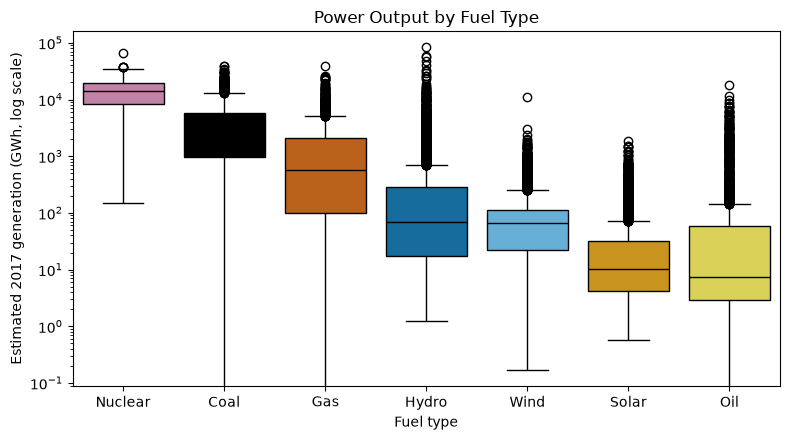

In [ ]:
sub = df_clean[df_clean["primary_fuel"].isin(TOP_FUELS)].dropna(
    subset=["generation_gwh_est"]
)
order = (
    sub.groupby("primary_fuel")["generation_gwh_est"]
    .median()
    .sort_values(ascending=False)
    .index
)

fig, ax = plt.subplots(figsize=(8, 4.5))
sns.boxplot(
    data=sub,
    x="primary_fuel",
    y="generation_gwh_est",
    order=order,
    ax=ax,
    palette=FUEL_COLORS,
    hue="primary_fuel",
    legend=False,
)
ax.set_yscale("log")
ax.set_xlabel("Fuel type")
ax.set_ylabel("Estimated 2017 generation (GWh, log scale)")
ax.set_title("Power Output by Fuel Type")
fig.tight_layout()
plt.show()

### 5c. Where are power plants concentrated?

A simple horizontal bar chart, sorted from most to fewest plants, so it's immediately
readable top-to-bottom without needing to compare bar lengths across the whole chart.


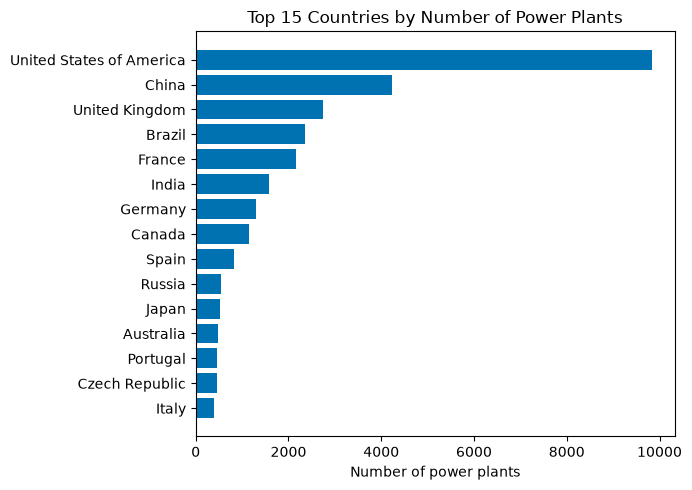

In [ ]:
top_countries = df_clean["country_long"].value_counts().head(15)

fig, ax = plt.subplots(figsize=(7, 5))
ax.barh(
    top_countries.index[::-1], top_countries.values[::-1], color=FUEL_COLORS["Hydro"]
)
ax.set_xlabel("Number of power plants")
ax.set_title("Top 15 Countries by Number of Power Plants")
fig.tight_layout()
plt.show()

### 5d. How has the energy mix changed over time?

We only have five real data points here - the 1970s, 1980s, ..., 2010s - so we use a
**100%-stacked bar chart**, not a smooth area chart. An area chart would draw a smooth
curve between decades, which visually implies we have data for every year in between
(like 1975 or 1985) - we don't. A bar per decade is the honest way to show five
distinct buckets without implying more continuity than the data actually has.


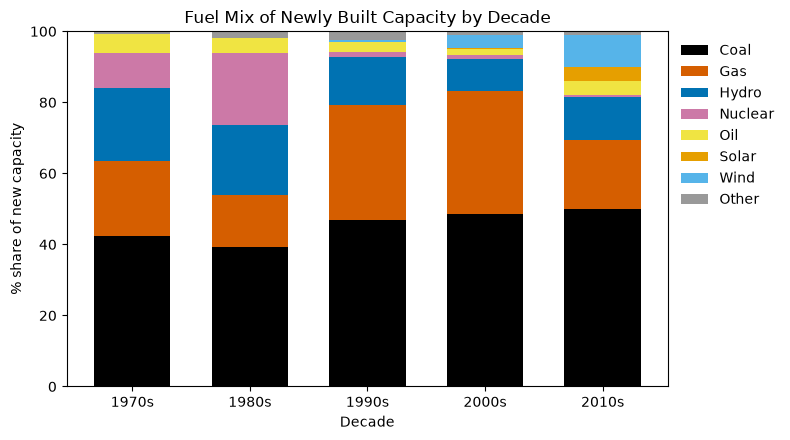

In [ ]:
have_year = df_clean.dropna(subset=["commissioning_year", "capacity_mw"]).copy()
have_year["decade"] = (have_year["commissioning_year"].astype(int) // 10) * 10
have_year = have_year[(have_year["decade"] >= 1970) & (have_year["decade"] < 2020)]
have_year["fuel_grouped"] = have_year["primary_fuel"].where(
    have_year["primary_fuel"].isin(TOP_FUELS), "Other"
)

pivot = pd.crosstab(
    have_year["decade"],
    have_year["fuel_grouped"],
    values=have_year["capacity_mw"],
    aggfunc="sum",
).fillna(0)
pivot_pct = pivot.div(pivot.sum(axis=1), axis=0) * 100
cols_order = [c for c in TOP_FUELS + ["Other"] if c in pivot_pct.columns]
pivot_pct = pivot_pct[cols_order]

fig, ax = plt.subplots(figsize=(8, 4.5))
bottom = np.zeros(len(pivot_pct))
x_labels = [f"{d}s" for d in pivot_pct.index]

for col in pivot_pct.columns:
    ax.bar(
        x_labels,
        pivot_pct[col],
        bottom=bottom,
        color=FUEL_COLORS[col],
        label=col,
        width=0.65,
    )
    bottom += pivot_pct[col].to_numpy()

ax.set_ylabel("% share of new capacity")
ax.set_xlabel("Decade")
ax.set_ylim(0, 100)
ax.set_title("Fuel Mix of Newly Built Capacity by Decade")
ax.legend(loc="upper left", bbox_to_anchor=(1.0, 1.0), frameon=False)
fig.tight_layout()
plt.show()

### 5e. Where in the world are these plants?

Plotting each plant's exact longitude and latitude as a dot, with no map image
underneath, actually reproduces the shape of the world's coastlines and borders on its
own - because that's just where the plants physically are. Color again follows fuel
type, so you can see at a glance, for example, that hydro plants cluster along
mountain/river regions rather than being evenly spread out.


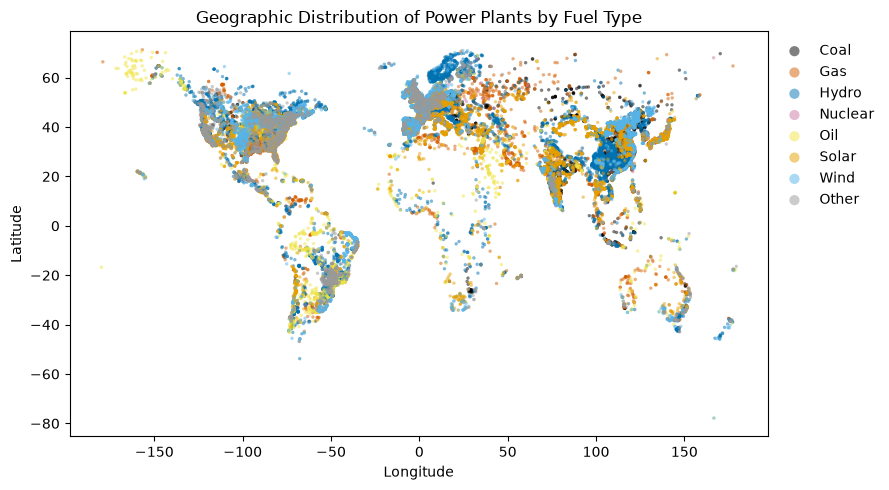

In [ ]:
geo = df_clean.copy()
geo["fuel_grouped"] = geo["primary_fuel"].where(
    geo["primary_fuel"].isin(TOP_FUELS), "Other"
)

fig, ax = plt.subplots(figsize=(9, 5))

for fuel in TOP_FUELS + ["Other"]:
    d = geo[geo["fuel_grouped"] == fuel]
    ax.scatter(
        d["longitude"],
        d["latitude"],
        s=6,
        alpha=0.5,
        color=FUEL_COLORS[fuel],
        label=fuel,
        edgecolors="none",
    )

ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("Geographic Distribution of Power Plants by Fuel Type")
ax.legend(loc="upper left", bbox_to_anchor=(1.0, 1.0), frameon=False, markerscale=3)
fig.tight_layout()
plt.show()

### 6. Matrix Operations in Real-World Context

A "matrix" here is just a table of numbers arranged in rows and columns - and it turns
out several things we've already done in this notebook (like `groupby().sum()`) are
secretly matrix operations underneath. This section makes that explicit with two
demonstrations:

**6a. Matrix multiplication as aggregation.** We turn `primary_fuel` into a matrix of
0s and 1s (one column per fuel type, a 1 marking which fuel type each plant has - this
is called "one-hot encoding"). Multiplying that matrix against the capacity numbers is
mathematically identical to "total capacity per fuel type" - we prove this by checking
it against `groupby().sum()` and confirming they match exactly.

**6b. Eigenvectors and eigenvalues, in plain terms.** We take five numeric attributes
(`capacity_mw`, `latitude`, `longitude`, `commissioning_year`, `generation_gwh_est`) and
ask: do any of them tend to move together? A correlation matrix answers that pairwise.
Eigenvectors/eigenvalues answer a related but bigger question: instead of looking at
attributes two at a time, can we find a small number of "combined directions" that
capture most of how plants actually vary? Concretely:

- An **eigenvector** is a specific mix of the original attributes (e.g. "70% capacity +
  70% generation, blended together") that behaves like a single new attribute.
- Its matching **eigenvalue** tells us how much of the total variation across all plants
  that one combined direction explains.
- If a small number of these combined directions explain most of the variation, it means
  the 5 original attributes weren't really "5 independent things" - some of them were
  telling us overlapping information. This is the core idea behind PCA (Principal
  Component Analysis), a technique built entirely out of eigenvectors/eigenvalues.


In [ ]:
def capacity_by_category_matrix(dataframe, category_col, value_col):
    """
    Aggregate a numeric column by category using one-hot encoding and matrix
    multiplication, instead of groupby to make explicit that groupby-sum is a matrix operation.

    Args:
        dataframe (pandas.DataFrame): The data containing the category and value columns.
        category_col (str): Name of the categorical column to group by (e.g. 'primary_fuel').
        value_col (str): Name of the numeric column to sum per category.

    Returns:
        pandas.Series: Total value_col per category, sorted descending, indexed
            by category name.
    """
    dummies = pd.get_dummies(dataframe[category_col])
    onehot_matrix = dummies.to_numpy(dtype=np.float64)
    values = dataframe[value_col].to_numpy(dtype=np.float64)

    # matrix (transposed) times vector: each output entry is "sum of values where
    # that category's column was 1". exactly what groupby().sum() computes
    totals = onehot_matrix.T @ values

    return pd.Series(totals, index=dummies.columns).sort_values(ascending=False)


def correlation_and_eigen(dataframe, columns):
    """
    Build a standardized correlation matrix for the given numeric columns and
    compute its eigenvalues/eigenvectors (a PCA-style decomposition).

    Args:
        dataframe (pandas.DataFrame): The data containing the columns to analyze.
        columns (list[str]): Names of the numeric columns to include.

    Returns:
        dict: 'correlation' (pandas.DataFrame correlation matrix), 'eigenvalues'
            (NumPy array, largest first), 'eigenvectors' (NumPy array, one
            column per eigenvector, matching eigenvalues order), 'explained_variance_pct'
            (each eigenvalue's share of total variance, as a percentage), and
            'n_rows' (how many complete-case rows were used).
    """
    feat = dataframe[columns].dropna().copy()

    for col in columns:
        feat[col] = feat[col].astype(np.float64)

    X = feat.to_numpy(dtype=np.float64)
    # standardize (z-score) each column. without this, capacity_mw (spanning
    # thousands) would dominate latitude (spanning -90 to 90) purely due to scale,
    # not because it's actually more variable in a meaningful sense
    X_std = (X - X.mean(axis=0)) / X.std(axis=0)

    corr = np.corrcoef(X_std, rowvar=False)

    # eigh (not eig) because a correlation matrix is symmetric. eigh is the
    # numerically stable choice for symmetric matrices and always returns real values
    eigvals, eigvecs = np.linalg.eigh(corr)
    order = np.argsort(eigvals)[::-1]
    eigvals = eigvals[order]
    eigvecs = eigvecs[:, order]
    explained_pct = eigvals / eigvals.sum() * 100

    return {
        "correlation": pd.DataFrame(corr, index=columns, columns=columns),
        "eigenvalues": eigvals,
        "eigenvectors": eigvecs,
        "explained_variance_pct": explained_pct,
        "n_rows": len(feat),
    }

In [ ]:
capacity_by_category_matrix(df_clean, "primary_fuel", "capacity_mw")

Coal              1.965541e+06
Gas               1.493051e+06
Hydro             1.053160e+06
Nuclear           4.079118e+05
Wind              2.630537e+05
Oil               2.618787e+05
Solar             1.883123e+05
Biomass           3.428130e+04
Waste             1.474871e+04
Geothermal        1.268775e+04
Cogeneration      4.048000e+03
Other             3.612860e+03
Petcoke           2.424577e+03
Storage           1.712300e+03
Wave and Tidal    5.522000e+02
dtype: float64

In [ ]:
feature_cols = [
    "capacity_mw",
    "latitude",
    "longitude",
    "commissioning_year",
    "generation_gwh_est",
]
result = correlation_and_eigen(df_clean, feature_cols)

print(f"Rows used (complete cases only): {result['n_rows']} of {len(df_clean)}")
print()
print("Correlation matrix:")
print(result["correlation"].round(2))
print()
print(
    "Explained variance % per eigenvector:", result["explained_variance_pct"].round(1)
)
print()
print("Top eigenvector (PC1) loadings:")
print(pd.Series(result["eigenvectors"][:, 0], index=feature_cols).round(3))

Rows used (complete cases only): 16653 of 34936

Correlation matrix:
                    capacity_mw  latitude  longitude  commissioning_year  \
capacity_mw                1.00     -0.00       0.34               -0.01   
latitude                  -0.00      1.00      -0.11               -0.15   
longitude                  0.34     -0.11       1.00               -0.02   
commissioning_year        -0.01     -0.15      -0.02                1.00   
generation_gwh_est         0.96     -0.01       0.35               -0.00   

                    generation_gwh_est  
capacity_mw                       0.96  
latitude                         -0.01  
longitude                         0.35  
commissioning_year               -0.00  
generation_gwh_est                1.00  

Explained variance % per eigenvector: [43.3 23.3 18.  14.6  0.8]

Top eigenvector (PC1) loadings:
capacity_mw          -0.651
latitude              0.043
longitude            -0.387
commissioning_year    0.009
generation_gwh_es

### 7. Integrating NumPy with Pandas and Matplotlib

This closing section makes explicit something that's been true throughout the notebook:
NumPy isn't a separate tool from Pandas and Matplotlib - Pandas is built on NumPy arrays
under the hood, and Matplotlib expects NumPy arrays as its input. Two focused examples:

**7a. NumPy driving a complex Pandas filter.** Rather than hand-picking capacity cutoffs,
we use `np.percentile` to _compute_ size-tier boundaries directly from the data, then
`np.select` to assign every plant a tier in one vectorized pass (no loop over 34,936 rows).
We then combine three NumPy boolean conditions at once (tier + build year + fuel type) to
answer a specific question: "which large renewable plants were built after 2010?"

**7b. NumPy powering a Matplotlib plot.** We use `np.polyfit` to fit a trend line through
the capacity-vs-generation relationship, then `np.linspace` to generate a smooth set of
x-values to draw that line with - Matplotlib itself has no idea what a "trend line" is,
it only draws points and lines; NumPy is what computes the line's shape.


In [ ]:
def tier_and_filter(dataframe, value_col, group_years_after, fuel_list):
    """
    Assign a size tier to each row via NumPy percentiles, then apply a
    multi-condition NumPy boolean filter across tier, build year, and fuel type.

    Args:
        dataframe (pandas.DataFrame): Data containing value_col, 'commissioning_year',
            and 'primary_fuel' columns.
        value_col (str): Numeric column to compute size tiers from (e.g. 'capacity_mw').
        group_years_after (int): Only keep rows commissioned after this year.
        fuel_list (list[str]): Only keep rows whose primary_fuel is in this list.

    Returns:
        tuple[pandas.DataFrame, pandas.Series]: The dataframe with a new
            'capacity_tier' column added, and the filtered subset matching all
            three conditions (Very Large tier, built after group_years_after,
            fuel type in fuel_list).
    """
    values = dataframe[value_col].to_numpy(dtype=np.float64)

    # thresholds computed from the data itself via NumPy, not hand-picked constants
    p33, p66, p90 = np.percentile(values, [33, 66, 90])

    # np.select evaluates all conditions at once across the whole array (vectorized),
    # instead of looping row by row or chaining many nested .apply() calls
    conditions = [values < p33, values < p66, values < p90]
    choices = ["Small", "Medium", "Large"]
    tiers = np.select(conditions, choices, default="Very Large")

    tagged = dataframe.copy()
    tagged["capacity_tier"] = tiers

    year_arr = tagged["commissioning_year"].to_numpy(
        dtype=np.float64
    )  # NaN-safe as float
    fuel_arr = tagged["primary_fuel"].to_numpy()

    # three NumPy boolean arrays combined with & into one filter mask
    mask = (
        (tiers == "Very Large")
        & (year_arr > group_years_after)
        & np.isin(fuel_arr, fuel_list)
    )

    return tagged, tagged.loc[mask]


def plot_capacity_vs_generation_with_trend(dataframe):
    """
    Scatter-plot capacity vs. generation on a log-log scale, with a NumPy-fitted
    trend line drawn on top.

    Args:
        dataframe (pandas.DataFrame): Data containing 'capacity_mw' and
            'generation_gwh_est' columns.

    Returns:
        tuple[float, float]: The fitted (slope, intercept) of the log-log trend line.
    """
    sub = dataframe.dropna(subset=["capacity_mw", "generation_gwh_est"])
    sub = sub[(sub["capacity_mw"] > 0) & (sub["generation_gwh_est"] > 0)]

    # fit a straight line in log-log space. equivalent to fitting a power-law
    # curve (generation ~ capacity^slope) in the original, non-logged space
    log_x = np.log10(sub["capacity_mw"].to_numpy())
    log_y = np.log10(sub["generation_gwh_est"].to_numpy())
    slope, intercept = np.polyfit(log_x, log_y, deg=1)

    # np.linspace generates smooth, evenly-spaced x-values for drawing the line.
    # Matplotlib just connects these points, NumPy is what makes the line "smooth"
    x_line = np.linspace(log_x.min(), log_x.max(), 100)
    y_line = slope * x_line + intercept

    fig, ax = plt.subplots(figsize=(7, 5))
    ax.scatter(
        sub["capacity_mw"], sub["generation_gwh_est"], s=5, alpha=0.3, color="#0072B2"
    )
    ax.plot(
        10**x_line,
        10**y_line,
        color="#D55E00",
        linewidth=2,
        label=f"NumPy fit (slope={slope:.2f})",
    )
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel("Capacity (MW, log scale)")
    ax.set_ylabel("Generation (GWh, log scale)")
    ax.set_title("Capacity vs Generation, with NumPy-fit trend line")
    ax.legend()
    fig.tight_layout()
    plt.show()

    return slope, intercept


In [ ]:
df_tiered, very_large_recent_renewables = tier_and_filter(
    df_clean,
    "capacity_mw",
    group_years_after=2010,
    fuel_list=["Solar", "Wind", "Hydro"],
)
print(df_tiered["capacity_tier"].value_counts())
print()
print(
    f"Very-large renewable plants built after 2010: {len(very_large_recent_renewables)}"
)
very_large_recent_renewables[
    ["name", "country_long", "primary_fuel", "capacity_mw", "commissioning_year"]
].head()


capacity_tier
Medium        11525
Small         11520
Large          8397
Very Large     3494
Name: count, dtype: int64

Very-large renewable plants built after 2010: 59


,name,country_long,primary_fuel,capacity_mw,commissioning_year
853,Kaprun Limberg II,Austria,Hydro,480.00000,2011
1385,Belo Monte,Brazil,Hydro,3327.45544,2016
1932,Estreito,Brazil,Hydro,1087.00000,2011
2257,Jirau,Brazil,Hydro,3750.00000,2013
3024,Santo Antônio,Brazil,Hydro,3568.00000,2012


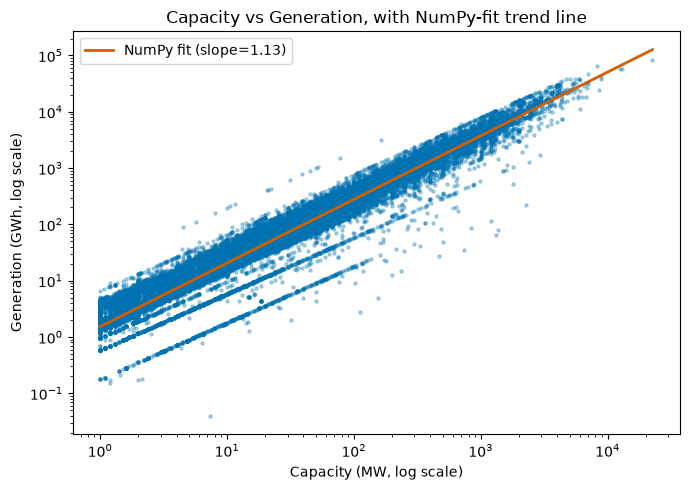

Fitted relationship: generation ≈ 10^0.19 × capacity^1.13


In [ ]:
slope, intercept = plot_capacity_vs_generation_with_trend(df_clean)
print(f"Fitted relationship: generation ≈ 10^{intercept:.2f} × capacity^{slope:.2f}")


### Final Report: Global Power Plant Database Analysis

### Overview

This analysis worked through the World Resources Institute Global Power Plant Database, covering 34,936 power plants across the world, using NumPy for numerical computation, Pandas for data handling, and Matplotlib and Seaborn for visualization. The goal was to understand plant capacity, power output, how the fuel mix has changed over time, and how different plant attributes relate to one another.

### Data Cleaning

Out of 36 original columns, the working dataset (`df_clean`) was narrowed to 10 columns that were actually needed for the analysis. The core columns used throughout, `capacity_mw`, `latitude`, `longitude`, and `primary_fuel`, had zero missing values. `commissioning_year` (the year a plant was built) was missing for about half of all plants (50.06%), and `estimated_generation_gwh_2017` (used as the main 'power output' metric) was 94.85% complete, making it far more usable than the other, sparser generation columns from the raw file. Some columns, such as `other_fuel1`, `other_fuel2`, and `other_fuel3`, were missing for the vast majority of rows for a structural reason: most plants only report a single fuel type, so a second or third fuel column is expected to be empty rather than broken. No duplicate plant IDs were found, and category labels such as `primary_fuel` had no whitespace or casing inconsistencies to clean up.

### What a Typical Plant Looks Like

Plant capacity is heavily skewed: the average plant has a capacity of about 163 MW, but the median plant is only about 17 MW, meaning a small number of very large plants (up to 22,500 MW) pull the average far above what a typical plant actually looks like. The same pattern shows up in power output: mean generation was about 716 GWh versus a median of just 37.6 GWh. Solar (30.5%) and Hydro (20.5%) are the most common fuel types by number of plants, while the United States (28.2%), China (12.1%), and the United Kingdom (7.9%) host the largest shares of plants by country.

### Power Output Differs by Fuel Type

Grouping plants by fuel type and comparing their estimated 2017 generation showed large, consistent differences. Nuclear plants averaged about 15,038 GWh of output, Coal about 4,186 GWh, and Gas about 1,526 GWh, while Solar (about 33 GWh) and Waste (about 7.7 GWh) sat at the low end. A hypothesis test was run to check whether these differences could simply be due to chance. Because generation is so heavily skewed, a standard test would not be reliable, so values were rank transformed first, and a permutation test (2,000 random reshuffles, built entirely with NumPy, since SciPy was not used) was used to measure how extreme the real result was compared to pure chance. The observed statistic (about 3,163) was thousands of times larger than anything produced by random shuffling, giving a p value below 0.001. This is strong evidence that power output really does differ by fuel type category, though it is worth being precise that this reflects a difference between categories of plant, not a claim that fuel type 'causes' output in an experimental sense. Five fuel types (Biomass, Cogeneration, Storage, Petcoke, and Wave and Tidal) had zero recorded generation values in this dataset and were excluded from this comparison entirely.

### Trends Over Time

Using the roughly half of plants with a known `commissioning_year`, total new capacity added per year showed an overall upward trend, averaging about plus 934 MW per year across the full 1896 to 2019 period (2020 was excluded as a partial, cut off year). The most recent few years in the data appeared to show a decline in new capacity, but this is most likely a reporting lag artifact (newly built plants often are not fully registered right away) rather than a genuine slowdown, and should not be read as a real trend without more data. Looking at the fuel mix of newly built capacity by decade told a clearer story: coal consistently made up 39% to 50% of all new capacity from the 1970s through the 2010s. Solar and wind were close to nonexistent before 2010, but jumped to 4.0% and 8.8% of new capacity respectively in the 2010s, a real and visible shift toward renewables in the most recent full decade of data.

### Visual Findings

Five charts were built, each chosen to match a specific question rather than defaulting to one chart type for everything. A logarithmic scale histogram confirmed the skewed capacity distribution described above. A boxplot of generation by fuel type (also on a logarithmic scale) visually confirmed the fuel type ranking from the hypothesis test, while also showing that some fuel types, such as Hydro and Oil, contain an especially wide range of plant sizes within the same category. A stacked bar chart (chosen over a smooth area chart, since only five decades of real data points exist) showed the fuel mix shift toward renewables described above. Finally, plotting each plant's raw latitude and longitude as a scatter point, with no map image underneath, reproduced the recognizable shape of the world's continents, and showed that fuel types are not evenly spread out geographically, hydro plants in particular cluster around mountain and river regions.

### Matrix Operations and Underlying Structure

Two demonstrations connected the dataset to matrix operations directly. First, encoding `primary_fuel` as a matrix of zeros and ones and multiplying it against the capacity numbers reproduced the exact same totals as a standard `groupby().sum()` (Coal about 1.97 million MW total, Gas about 1.49 million, Hydro about 1.05 million), confirming that aggregation is, underneath, a matrix operation. Second, a correlation matrix and eigen decomposition were computed across five numeric attributes (capacity, latitude, longitude, commissioning year, and generation). Capacity and generation correlated at 0.96, nearly the maximum possible, meaning these two columns carry almost the same information about a plant rather than two independent facts. This showed up numerically in the eigen decomposition too: the first and largest combined direction (explaining 43.3% of all variation) was made up almost entirely of capacity and generation blended together. A second combined direction (23.3% of variation) was dominated by latitude and commissioning year, suggesting a separate 'where and when' axis of variation that is distinct from plant size. This part of the analysis used only the roughly 16,653 plants with complete data across all five attributes.

### NumPy Working Together with Pandas and Matplotlib

The final task tied the three libraries together directly. NumPy's percentile function was used to compute size tier boundaries (Small, Medium, Large, Very Large) straight from the data rather than guessing fixed cutoffs, and NumPy's boolean array operations combined three conditions at once (size tier, build year, and fuel type) to find 59 very large renewable plants built after 2010, including Belo Monte and Jirau in Brazil. Separately, NumPy's line fitting function was used to fit a trend line to capacity versus generation on a logarithmic scale for both axes, and NumPy generated the smooth set of points Matplotlib used to draw that line. The fitted relationship had a slope of about 1.13, close to a direct one to one proportional relationship between capacity and generation, matching physical expectations. A visible band of plants sitting well below this line represents lower utilization plants, ones that produce less energy than their installed capacity alone would suggest.

### Key Insights

1. Capacity and generation are nearly redundant as attributes (correlation of 0.96), so treating them as fully independent signals somewhat overstates how much distinct information the dataset actually contains about a plant.
2. Fuel type has a large and statistically confirmed relationship with power output, with nuclear and coal plants far outproducing solar and waste on average, even though solar is the single most common fuel type by plant count.
3. The shift toward renewable energy is real and recent: solar and wind were nearly absent from new capacity before 2010 and became a meaningfully sized share (over 12% combined) of new capacity in the 2010s.
4. Roughly half of all plants are missing a build year, and several fuel types have no recorded generation data at all, so any time based or output based conclusion in this report should be read as describing the reporting subset of the database, not necessarily every plant in the world.

### Limitations

The 'power output' figure used throughout is a single estimated year (2017), not an average across multiple years, since it was by far the most complete generation column available. The apparent decline in new capacity in the final years of the dataset is most likely a data reporting lag rather than a true recent slowdown. The hypothesis test in Task 3 shows that at least one fuel type differs from the others, but does not by itself identify every individual pair that differs significantly, that would require additional pairwise testing beyond the scope of this analysis. Finally, several steps (the eigen decomposition, and the fuel mix by decade breakdown) rely on subsets of the data with complete values in the relevant columns, and those subsets are smaller than the full dataset.
